# 🚗 Week 2 Assignment — End-to-End ML Pipeline on Tesla EV Sales & Price Data

**Author:** Deeptesh Mohapatra
**Dataset:** [Tesla EV Deliveries and Production Data (2015–2025)](https://www.kaggle.com/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025)

---

## 🎯 Problem Statement
Design and implement a **complete, end-to-end machine-learning pipeline** on Tesla's
electric-vehicle sales/price data. The pipeline covers the full lifecycle:

| Stage | What we do |
|-------|------------|
| **1. Data Loading** | Pull the dataset directly from Kaggle via `kagglehub` |
| **2. Preprocessing** | Type checks, missing values, duplicates, datetime construction |
| **3. EDA** | Distributions, trends, seasonality, correlations |
| **4. Feature Engineering** | Cyclical time features, encoding, scaling, leakage removal |
| **5. Regression Modeling** | Train & compare 6 regression models |
| **6. Hyperparameter Tuning** | Cross-validated `RandomizedSearchCV` + diagnostics |
| **7. Time-Series Forecasting** | Decomposition, stationarity, SARIMA & Holt-Winters |

**Modeling targets**
- **Regression target → `Estimated_Deliveries`** (the *sales* signal; it is genuinely predictable).
- **Forecasting target → monthly total deliveries** (2015-01 → 2025-12).

## ⚙️ Setup & Imports

In [1]:
# Core
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# scikit-learn
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# statsmodels (time series)
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print('All imports OK')

All imports OK


---
## 1️⃣ Data Loading
We download the dataset straight from Kaggle using `kagglehub`. The call is cached,
so re-running is instant.

In [2]:
import kagglehub
import os, glob

path = kagglehub.dataset_download('nalisha/tesla-ea-deliveries-and-production-data20152025')
print('Dataset folder:', path)

csv_file = glob.glob(os.path.join(path, '*.csv'))[0]
print('CSV file:', os.path.basename(csv_file))

df = pd.read_csv(csv_file)
print('Loaded shape:', df.shape)
df.head()

Dataset folder: C:\Users\lenovo\.cache\kagglehub\datasets\nalisha\tesla-ea-deliveries-and-production-data20152025\versions\1
CSV file: tesla_deliveries_dataset_2015_2025.csv
Loaded shape: (2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


---
## 2️⃣ Data Understanding & Preprocessing
Before modeling we verify structure, types, missing values, duplicates, and build a
proper datetime index.

In [3]:
# Structure & dtypes
print('Rows, Cols:', df.shape)
df.info()

Rows, Cols: (2640, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [4]:
# Statistical summary of numeric columns
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Year,2640.0,2020.00,3.16,2015.00,2017.00,2020.00,2023.00,2025.00
Month,2640.0,6.50,3.45,1.00,3.75,6.50,9.25,12.00
Estimated_Deliveries,2640.0,9922.20,3935.95,48.00,7292.00,9857.00,12510.25,25704.00
Production_Units,2640.0,10655.85,4260.60,50.00,7828.25,10546.50,13469.00,28939.00
Avg_Price_USD,2640.0,84907.34,20123.26,50003.70,67726.36,85058.51,102373.04,119965.36
Battery_Capacity_kWh,2640.0,87.06,20.84,60.00,75.00,82.00,100.00,120.00
Range_km,2640.0,500.26,120.87,330.00,418.00,470.00,586.25,719.00
CO2_Saved_tons,2640.0,744.08,353.22,3.07,499.62,699.52,943.76,2548.55
Charging_Stations,2640.0,8932.13,3469.57,3002.00,5897.75,8901.50,11938.00,14996.00


In [5]:
# Categorical columns – cardinality
cat_cols = df.select_dtypes('object').columns.tolist()
for c in cat_cols:
    print(f"{c:14s} ({df[c].nunique()} unique): {sorted(df[c].unique())}")

Region         (4 unique): ['Asia', 'Europe', 'Middle East', 'North America']
Model          (5 unique): ['Cybertruck', 'Model 3', 'Model S', 'Model X', 'Model Y']
Source_Type    (3 unique): ['Estimated (Region)', 'Interpolated (Month)', 'Official (Quarter)']


In [6]:
# Missing values & duplicates
print('Missing values per column:')
print(df.isnull().sum())
print('\nTotal missing:', df.isnull().sum().sum())
print('Duplicate rows :', df.duplicated().sum())

Missing values per column:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Total missing: 0
Duplicate rows : 0


In [7]:
# This panel = Year x Month x Region x Model. Confirm it is balanced.
print('Years  :', df.Year.min(), '->', df.Year.max(), '(', df.Year.nunique(), 'years )')
print('Months :', df.Month.nunique())
print('Regions:', df.Region.nunique(), '| Models:', df.Model.nunique())
print('Expected rows = 11*12*4*5 =', 11*12*4*5, '| Actual =', len(df))

# Build a proper monthly datetime column (first of month)
df['Date'] = pd.to_datetime(dict(year=df.Year, month=df.Month, day=1))
df = df.sort_values('Date').reset_index(drop=True)
df[['Year','Month','Date','Region','Model','Estimated_Deliveries']].head()

Years  : 2015 -> 2025 ( 11 years )
Months : 12
Regions: 4 | Models: 5
Expected rows = 11*12*4*5 = 2640 | Actual = 2640


,Year,Month,Date,Region,Model,Estimated_Deliveries
0,2015,1,2015-01-01,Asia,Model Y,12446
1,2015,1,2015-01-01,Middle East,Model 3,11446
2,2015,1,2015-01-01,Middle East,Cybertruck,8803
3,2015,1,2015-01-01,North America,Cybertruck,6367
4,2015,1,2015-01-01,Asia,Model 3,8795


**Preprocessing notes**
- The dataset is a **clean, balanced panel**: every (Year, Month, Region, Model) combination
  appears exactly once → 2,640 rows, **zero missing values, zero duplicates**.
- Because it is clean we don't need imputation, but the pipeline below still wires up an
  imputation-safe `ColumnTransformer` so it generalizes to messy data.
- We created a `Date` column so the series can be analyzed chronologically in Part 7.

---
## 3️⃣ Exploratory Data Analysis (EDA)

### 3.1 Distributions of the numeric features

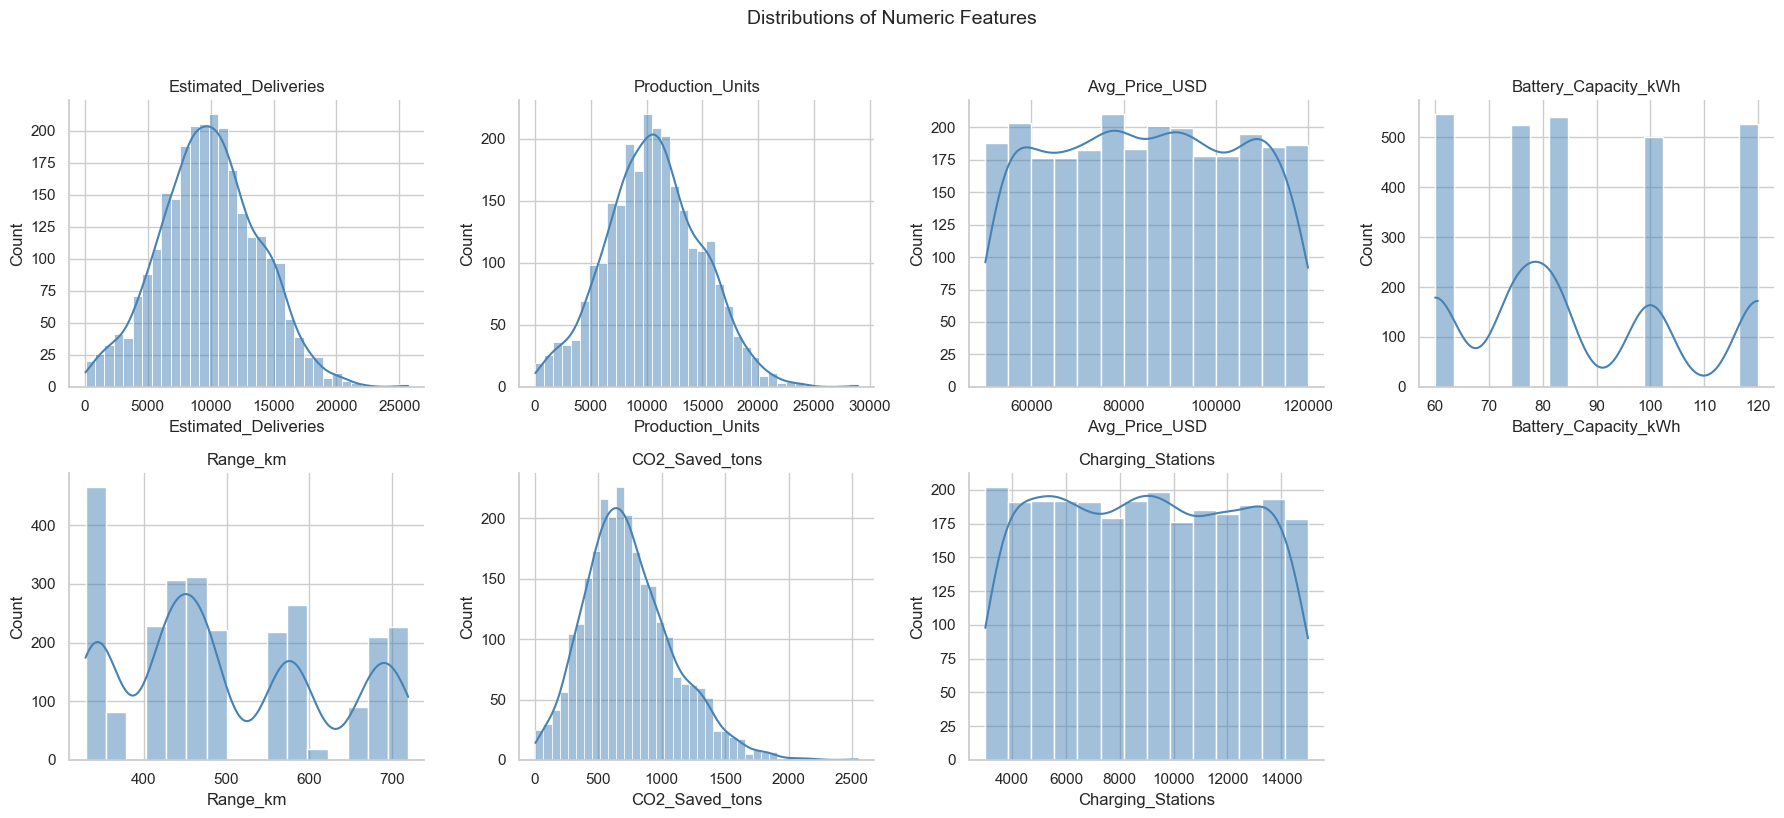

In [8]:
num_cols = ['Estimated_Deliveries','Production_Units','Avg_Price_USD',
            'Battery_Capacity_kWh','Range_km','CO2_Saved_tons','Charging_Stations']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(col)
axes.flat[-1].axis('off')
plt.suptitle('Distributions of Numeric Features', y=1.02, fontsize=14)
plt.tight_layout(); plt.show()

### 3.2 Deliveries & production trend over time

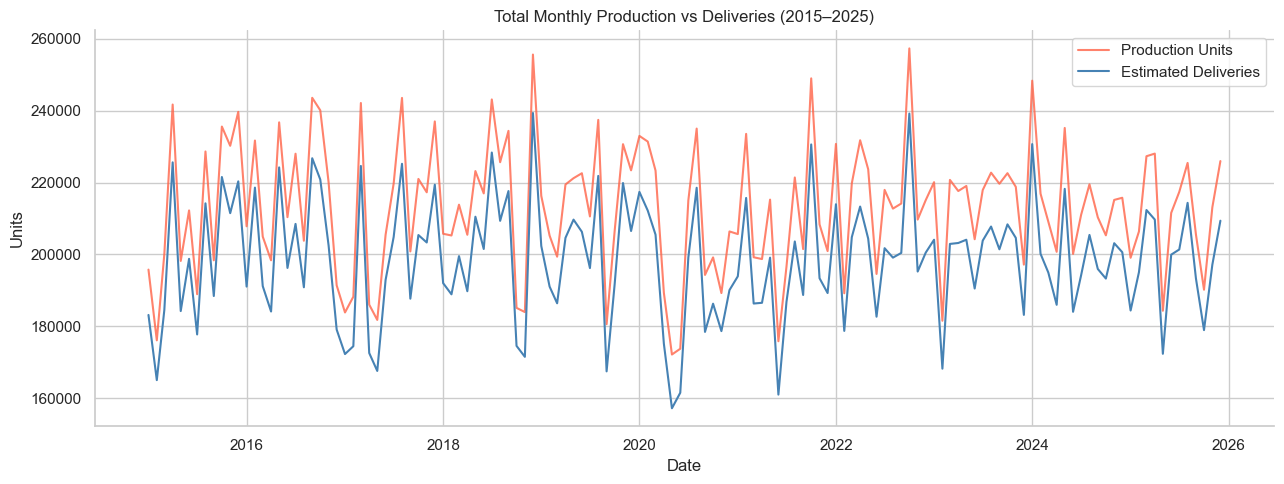

Yearly total deliveries:
Year
2015    2375267
2016    2434081
2017    2350517
2018    2423104
2019    2404230
2020    2280336
2021    2335116
2022    2434220
2023    2382375
2024    2406899
2025    2368462
Name: Estimated_Deliveries, dtype: int64


In [9]:
monthly = df.groupby('Date')[['Estimated_Deliveries','Production_Units']].sum()
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(monthly.index, monthly['Production_Units'], label='Production Units', color='tomato', alpha=0.8)
ax.plot(monthly.index, monthly['Estimated_Deliveries'], label='Estimated Deliveries', color='steelblue')
ax.set_title('Total Monthly Production vs Deliveries (2015–2025)')
ax.set_xlabel('Date'); ax.set_ylabel('Units'); ax.legend()
plt.tight_layout(); plt.show()

print('Yearly total deliveries:')
print(df.groupby('Year')['Estimated_Deliveries'].sum())

### 3.3 Deliveries by Model and Region

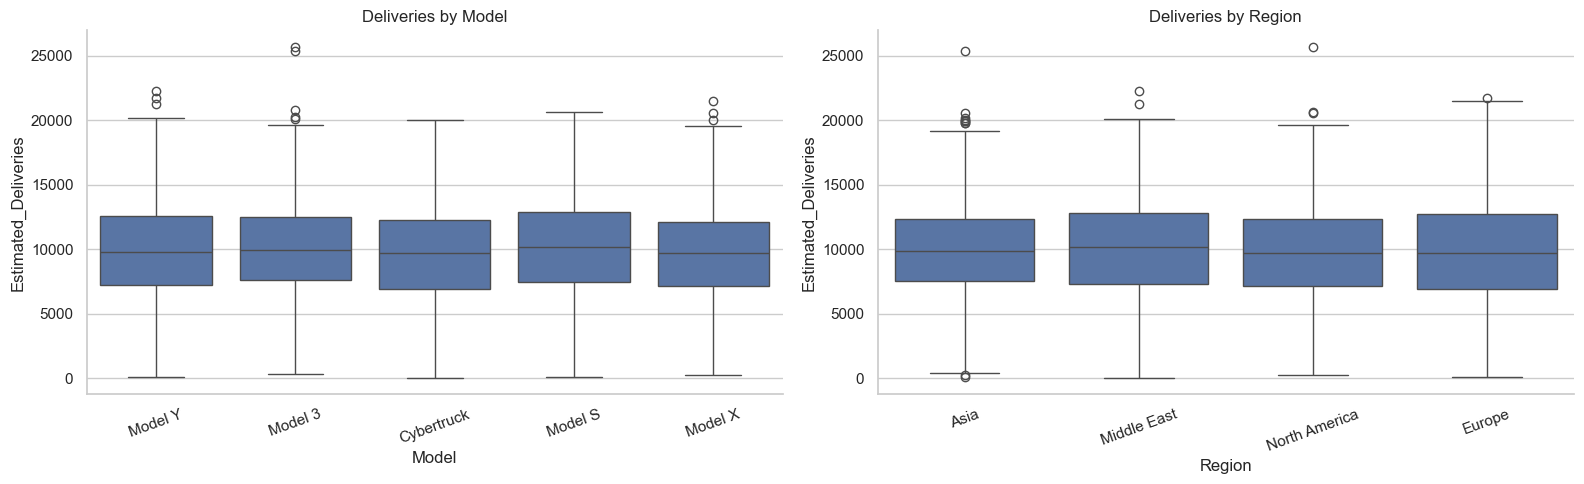

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(data=df, x='Model', y='Estimated_Deliveries', ax=axes[0])
axes[0].set_title('Deliveries by Model'); axes[0].tick_params(axis='x', rotation=20)
sns.boxplot(data=df, x='Region', y='Estimated_Deliveries', ax=axes[1])
axes[1].set_title('Deliveries by Region'); axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

### 3.4 Average price by model & price distribution

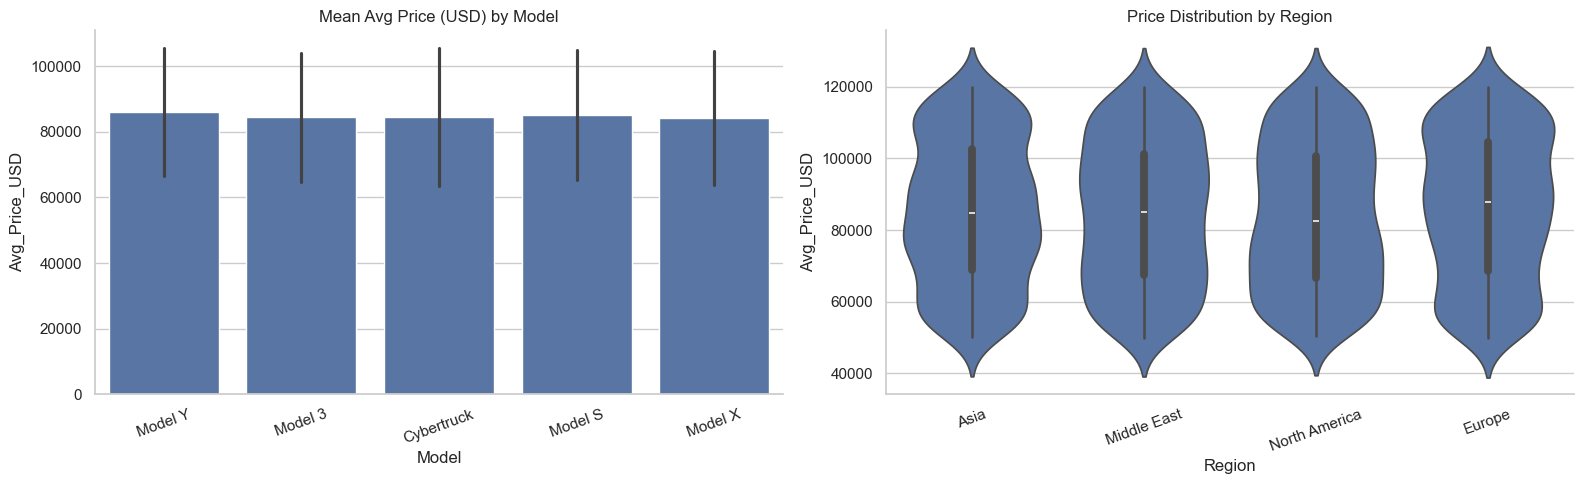

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=df, x='Model', y='Avg_Price_USD', ax=axes[0], estimator=np.mean, errorbar='sd')
axes[0].set_title('Mean Avg Price (USD) by Model'); axes[0].tick_params(axis='x', rotation=20)
sns.violinplot(data=df, x='Region', y='Avg_Price_USD', ax=axes[1])
axes[1].set_title('Price Distribution by Region'); axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

### 3.5 Correlation heatmap

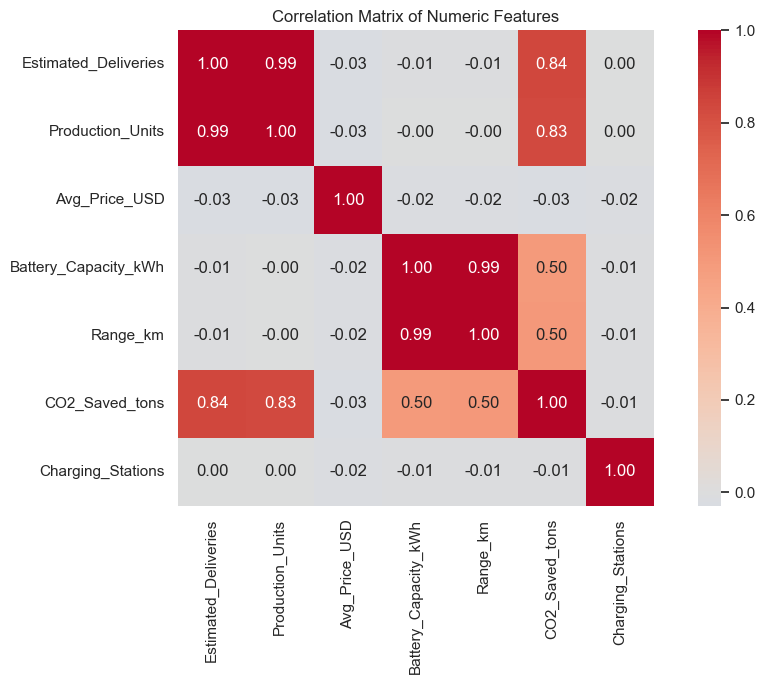

In [12]:
plt.figure(figsize=(10, 7))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout(); plt.show()

### 3.6 Monthly seasonality

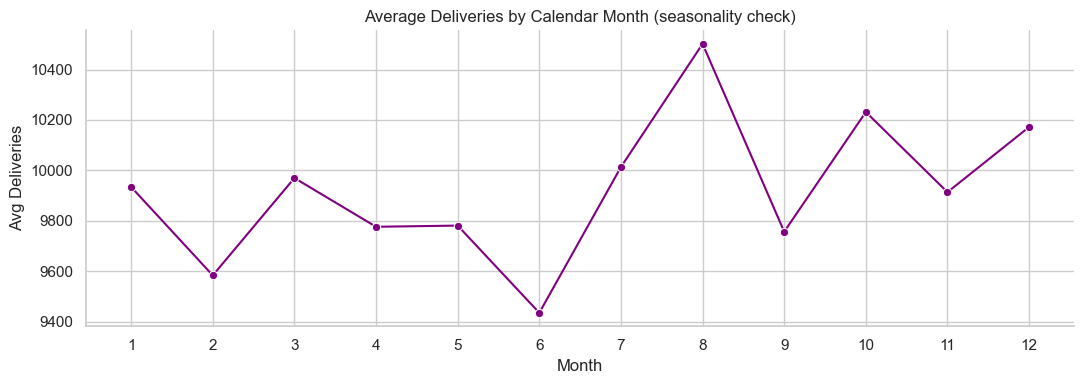

In [13]:
month_avg = df.groupby('Month')['Estimated_Deliveries'].mean()
fig, ax = plt.subplots(figsize=(11, 4))
sns.lineplot(x=month_avg.index, y=month_avg.values, marker='o', ax=ax, color='purple')
ax.set_title('Average Deliveries by Calendar Month (seasonality check)')
ax.set_xlabel('Month'); ax.set_ylabel('Avg Deliveries'); ax.set_xticks(range(1,13))
plt.tight_layout(); plt.show()

**🔍 EDA Findings**
- **`Estimated_Deliveries` ≈ `Production_Units`** (r ≈ 0.99) and strongly tracks **`CO2_Saved_tons`** (r ≈ 0.84) — CO₂ saved is a *downstream consequence* of how many cars are delivered.
- **`Battery_Capacity_kWh` ≈ `Range_km`** (r ≈ 0.99) — these two are essentially redundant.
- **`Avg_Price_USD` is uncorrelated with everything** (|r| < 0.03) — price behaves like noise here, so it is a poor regression target. We therefore model **deliveries**, not price.
- Deliveries are **roughly flat year-over-year** (~2.4 M/yr) with mild month-to-month variation → the time series is close to stationary.

---
## 4️⃣ Feature Engineering
We engineer time features, **remove leakage**, and define the model matrix.

**Leakage control:** `CO2_Saved_tons` is computed *from* deliveries, so feeding it to a model
that predicts deliveries would leak the answer. We **drop it** from the feature set.

In [14]:
fe = df.copy()

# --- Cyclical encoding of month (so Dec is 'close to' Jan) ---
fe['month_sin'] = np.sin(2 * np.pi * fe['Month'] / 12)
fe['month_cos'] = np.cos(2 * np.pi * fe['Month'] / 12)

# --- Calendar / trend features ---
fe['Quarter']    = fe['Date'].dt.quarter
fe['time_index'] = (fe['Date'].dt.year - 2015) * 12 + (fe['Date'].dt.month - 1)  # 0..131

TARGET = 'Estimated_Deliveries'
LEAKAGE = ['CO2_Saved_tons']          # downstream of the target
DROP    = ['Date', 'Year', TARGET] + LEAKAGE

numeric_features = ['Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh',
                    'Range_km', 'Charging_Stations', 'Month', 'Quarter',
                    'month_sin', 'month_cos', 'time_index']
categorical_features = ['Region', 'Model', 'Source_Type']

X = fe[numeric_features + categorical_features]
y = fe[TARGET]
print('Feature matrix X:', X.shape)
print('Numeric   :', numeric_features)
print('Categorical:', categorical_features)
X.head()

Feature matrix X: (2640, 13)
Numeric   : ['Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'Charging_Stations', 'Month', 'Quarter', 'month_sin', 'month_cos', 'time_index']
Categorical: ['Region', 'Model', 'Source_Type']


,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,Charging_Stations,Month,Quarter,month_sin,month_cos,time_index,Region,Model,Source_Type
0,13885,55183.13,60,340,4390,1,1,0.5,0.866025,0,Asia,Model Y,Official (Quarter)
1,12752,89289.40,100,588,8925,1,1,0.5,0.866025,0,Middle East,Model 3,Estimated (Region)
2,9344,102888.58,60,336,3923,1,1,0.5,0.866025,0,Middle East,Cybertruck,Interpolated (Month)
3,6802,104962.32,82,459,9170,1,1,0.5,0.866025,0,North America,Cybertruck,Estimated (Region)
4,9165,87988.73,82,456,12626,1,1,0.5,0.866025,0,Asia,Model 3,Official (Quarter)


### 4.1 Train/test split & preprocessing pipeline
`ColumnTransformer` scales numeric columns and one-hot-encodes categoricals. Because it is
fit **inside** the pipeline on the training fold only, there is **no train→test leakage**.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)
print('Train:', X_train.shape, '| Test:', X_test.shape)

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
])
print('Preprocessor ready.')

Train: (2112, 13) | Test: (528, 13)
Preprocessor ready.


---
## 5️⃣ Regression Modeling
We train **six** models inside identical pipelines and compare them on the held-out test set
using MAE, RMSE and R².

In [16]:
def evaluate(name, model, X_te, y_te):
    pred = model.predict(X_te)
    return {
        'Model': name,
        'MAE':  mean_absolute_error(y_te, pred),
        'RMSE': np.sqrt(mean_squared_error(y_te, pred)),
        'R2':   r2_score(y_te, pred),
    }

models = {
    'Linear Regression':  LinearRegression(),
    'Ridge':              Ridge(alpha=1.0, random_state=RANDOM_STATE),
    'Lasso':              Lasso(alpha=1.0, random_state=RANDOM_STATE),
    'Decision Tree':      DecisionTreeRegressor(random_state=RANDOM_STATE),
    'Random Forest':      RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting':  GradientBoostingRegressor(random_state=RANDOM_STATE),
}

results = []
fitted = {}
for name, est in models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', est)])
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    results.append(evaluate(name, pipe, X_test, y_test))

results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
results_df.round(3)

,Model,MAE,RMSE,R2
0,Lasso,332.549,414.760,0.989
1,Ridge,333.057,415.223,0.988
2,Linear Regression,333.032,415.374,0.988
3,Gradient Boosting,342.126,428.024,0.988
4,Random Forest,343.866,437.709,0.987
5,Decision Tree,476.011,614.422,0.975


### 5.1 Visual comparison of models

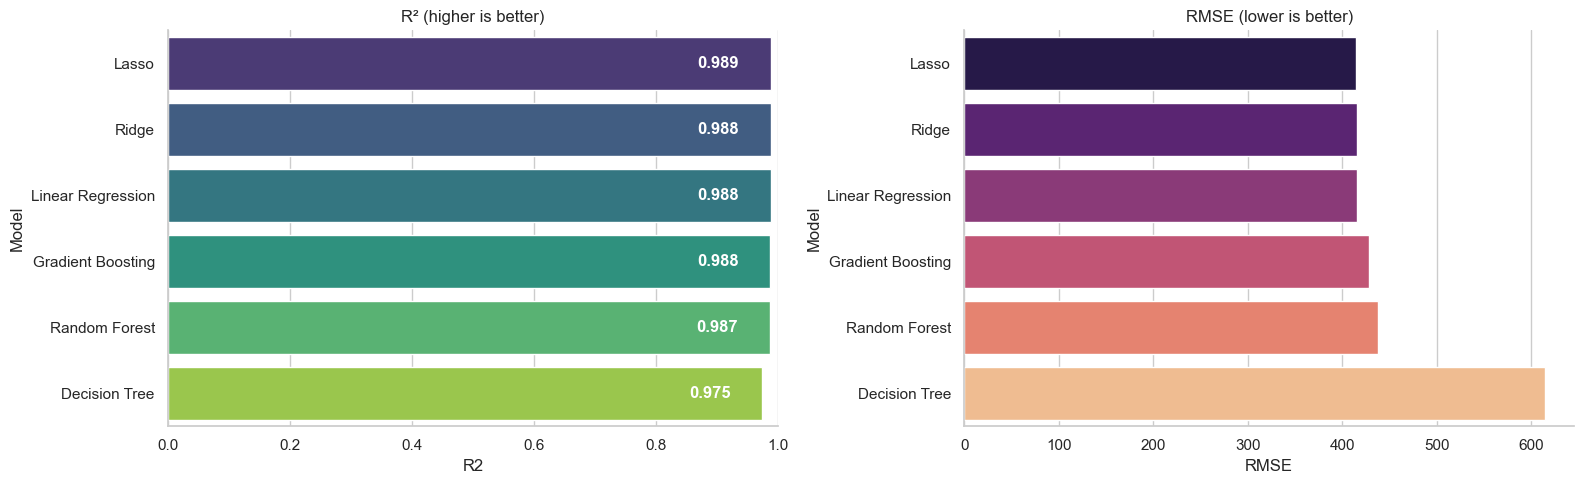

Best baseline model: Lasso


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
order = results_df.sort_values('R2', ascending=False)
sns.barplot(data=order, x='R2', y='Model', ax=axes[0], palette='viridis')
axes[0].set_title('R² (higher is better)'); axes[0].set_xlim(0, 1)
for i, v in enumerate(order['R2']):
    axes[0].text(v - 0.12, i, f'{v:.3f}', color='white', va='center', fontweight='bold')

order2 = results_df.sort_values('RMSE')
sns.barplot(data=order2, x='RMSE', y='Model', ax=axes[1], palette='magma')
axes[1].set_title('RMSE (lower is better)')
plt.tight_layout(); plt.show()

best_name = results_df.iloc[0]['Model']
print('Best baseline model:', best_name)

---
## 6️⃣ Hyperparameter Tuning
We tune a **Random Forest** with 5-fold cross-validated `RandomizedSearchCV`
(optimizing R²), then evaluate the tuned model and inspect diagnostics.

> *Note:* the linear models edged the baseline leaderboard (the deliveries↔production link is
> almost perfectly linear), but we demonstrate tuning on a **Random Forest** because it exposes
> many more hyperparameters to search — linear models have very little to tune.

In [18]:
rf_pipe = Pipeline([('prep', preprocessor),
                    ('model', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))])

param_dist = {
    'model__n_estimators':      [100, 200, 300, 500],
    'model__max_depth':         [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf':  [1, 2, 4],
    'model__max_features':      ['sqrt', 'log2', 1.0],
}

search = RandomizedSearchCV(
    rf_pipe, param_distributions=param_dist, n_iter=25, cv=5,
    scoring='r2', random_state=RANDOM_STATE, n_jobs=-1, verbose=1)
search.fit(X_train, y_train)

print('\nBest CV R²    :', round(search.best_score_, 4))
print('Best parameters:')
for k, v in search.best_params_.items():
    print(f'   {k} = {v}')

Fitting 5 folds for each of 25 candidates, totalling 125 fits



Best CV R²    : 0.9861
Best parameters:
   model__n_estimators = 500
   model__min_samples_split = 2
   model__min_samples_leaf = 1
   model__max_features = 1.0
   model__max_depth = None


In [19]:
# Evaluate tuned model on the held-out test set
best_model = search.best_estimator_
tuned = evaluate('Random Forest (tuned)', best_model, X_test, y_test)

compare = pd.DataFrame([
    results_df[results_df.Model == 'Random Forest'].iloc[0].to_dict(),
    tuned,
])
print('Baseline vs Tuned Random Forest:')
compare.round(3)

Baseline vs Tuned Random Forest:


,Model,MAE,RMSE,R2
0,Random Forest,343.866,437.709,0.987
1,Random Forest (tuned),343.497,436.995,0.987


### 6.1 Feature importances

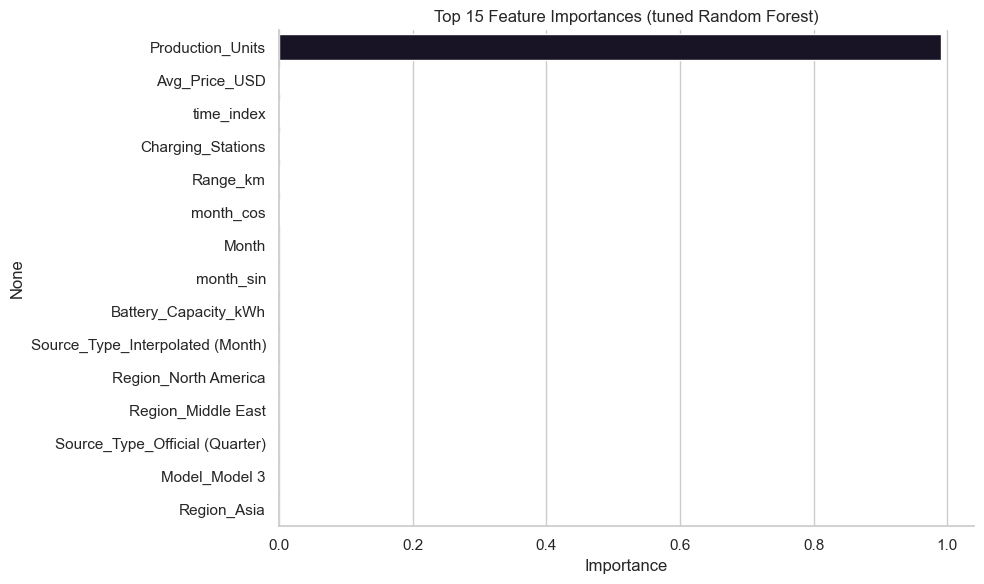

Production_Units                    0.9907
Avg_Price_USD                       0.0015
time_index                          0.0014
Charging_Stations                   0.0014
Range_km                            0.0012
month_cos                           0.0006
Month                               0.0005
month_sin                           0.0005
Battery_Capacity_kWh                0.0002
Source_Type_Interpolated (Month)    0.0002
Region_North America                0.0002
Region_Middle East                  0.0002
Source_Type_Official (Quarter)      0.0002
Model_Model 3                       0.0002
Region_Asia                         0.0002
dtype: float64

In [20]:
# Recover feature names out of the ColumnTransformer
ohe = best_model.named_steps['prep'].named_transformers_['cat']
ohe_names = ohe.get_feature_names_out(categorical_features).tolist()
feat_names = numeric_features + ohe_names

importances = best_model.named_steps['model'].feature_importances_
imp = pd.Series(importances, index=feat_names).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=imp.values, y=imp.index, palette='rocket')
plt.title('Top 15 Feature Importances (tuned Random Forest)')
plt.xlabel('Importance'); plt.tight_layout(); plt.show()
imp.round(4)

### 6.2 Residual diagnostics

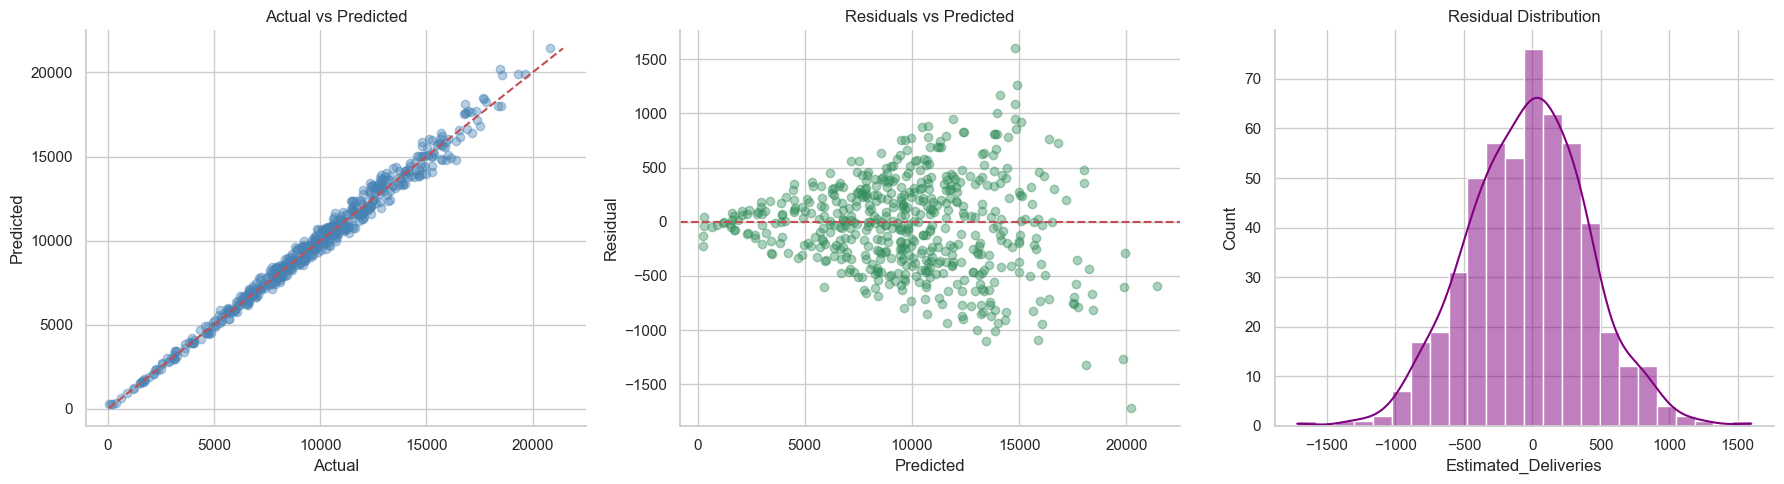

Residual mean: -33.73  | Residual std: 436.10


In [21]:
pred_test = best_model.predict(X_test)
residuals = y_test - pred_test

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# Actual vs Predicted
axes[0].scatter(y_test, pred_test, alpha=0.4, color='steelblue')
lims = [min(y_test.min(), pred_test.min()), max(y_test.max(), pred_test.max())]
axes[0].plot(lims, lims, 'r--')
axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted'); axes[0].set_title('Actual vs Predicted')
# Residuals vs Predicted
axes[1].scatter(pred_test, residuals, alpha=0.4, color='seagreen')
axes[1].axhline(0, color='r', ls='--')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Residual'); axes[1].set_title('Residuals vs Predicted')
# Residual distribution
sns.histplot(residuals, kde=True, ax=axes[2], color='purple')
axes[2].set_title('Residual Distribution')
plt.tight_layout(); plt.show()

print(f'Residual mean: {residuals.mean():.2f}  | Residual std: {residuals.std():.2f}')

---
## 7️⃣ Time-Series Forecasting
We aggregate to a **monthly total-deliveries** series (132 months) and forecast it.

Series span: 2015-01-01 -> 2025-12-01 | points: 132


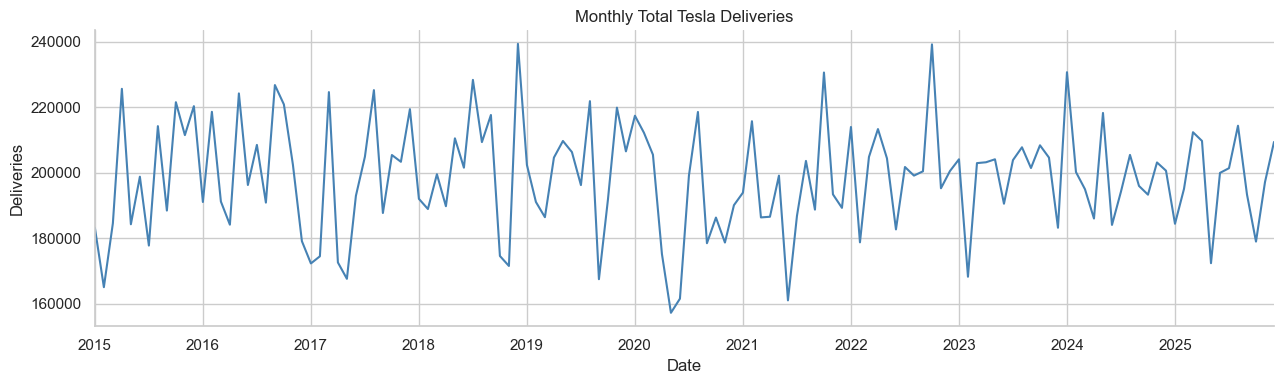

In [22]:
ts = df.groupby('Date')['Estimated_Deliveries'].sum().asfreq('MS')
print('Series span:', ts.index.min().date(), '->', ts.index.max().date(), '| points:', len(ts))

fig, ax = plt.subplots(figsize=(13, 4))
ts.plot(ax=ax, color='steelblue')
ax.set_title('Monthly Total Tesla Deliveries'); ax.set_ylabel('Deliveries')
plt.tight_layout(); plt.show()

### 7.1 Seasonal decomposition

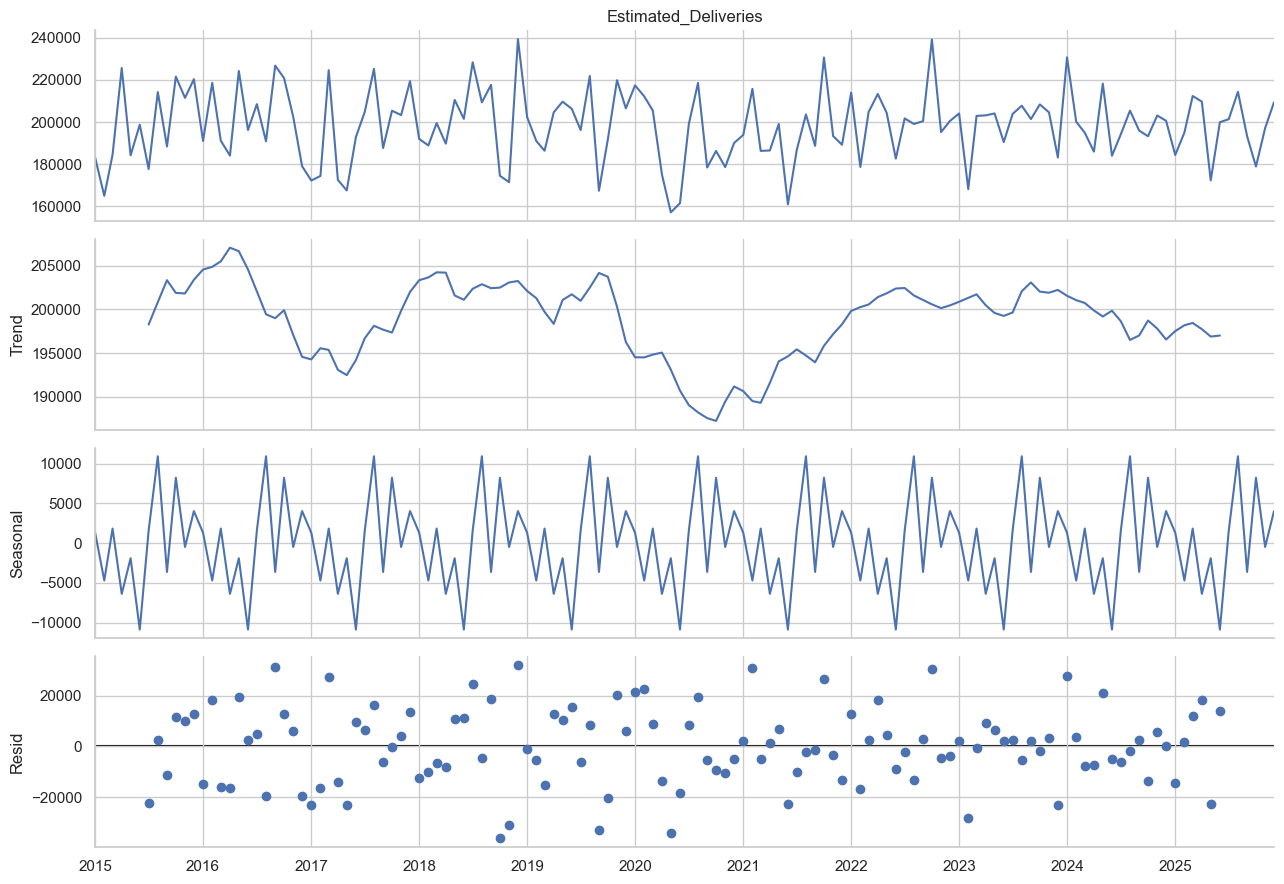

In [23]:
decomp = seasonal_decompose(ts, model='additive', period=12)
fig = decomp.plot()
fig.set_size_inches(13, 9)
plt.tight_layout(); plt.show()

### 7.2 Stationarity — Augmented Dickey-Fuller test

In [24]:
def adf_report(series, label):
    stat, p, *_ = adfuller(series.dropna())
    print(f'{label:22s} ADF={stat:8.4f}  p={p:.4f}  -> {"stationary" if p < 0.05 else "NON-stationary"}')

adf_report(ts, 'Original series')
adf_report(ts.diff(), 'After 1st differencing')

Original series        ADF= -8.8810  p=0.0000  -> stationary
After 1st differencing ADF= -7.0101  p=0.0000  -> stationary


### 7.3 Train/test split & models
We hold out the **last 24 months** as the test horizon and compare three approaches.

In [25]:
h = 24
train_ts, test_ts = ts[:-h], ts[-h:]
print('Train:', len(train_ts), 'months | Test:', len(test_ts), 'months')

def ts_metrics(name, actual, forecast):
    actual, forecast = np.asarray(actual), np.asarray(forecast)
    mae  = mean_absolute_error(actual, forecast)
    rmse = np.sqrt(mean_squared_error(actual, forecast))
    mape = np.mean(np.abs((actual - forecast) / actual)) * 100
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'MAPE_%': mape}

# (a) Seasonal-naive baseline: repeat the value from 12 months earlier
snaive = [train_ts.iloc[-12 + (i % 12)] for i in range(h)]
snaive = pd.Series(snaive, index=test_ts.index)

# (b) Holt-Winters (additive trend + additive seasonality)
hw = ExponentialSmoothing(train_ts, trend='add', seasonal='add',
                          seasonal_periods=12).fit()
hw_fc = hw.forecast(h)

# (c) SARIMA
sarima = SARIMAX(train_ts, order=(1, 1, 1), seasonal_order=(1, 0, 1, 12),
                 enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
sarima_fc = sarima.forecast(h)

ts_results = pd.DataFrame([
    ts_metrics('Seasonal Naive', test_ts, snaive),
    ts_metrics('Holt-Winters',   test_ts, hw_fc),
    ts_metrics('SARIMA',         test_ts, sarima_fc),
]).sort_values('RMSE').reset_index(drop=True)
ts_results.round(2)

Train: 108 months | Test: 24 months


,Model,MAE,RMSE,MAPE_%
0,SARIMA,9969.23,12885.72,5.01
1,Holt-Winters,10352.73,14488.73,5.16
2,Seasonal Naive,14149.21,17135.02,7.22


### 7.4 Forecast vs actual

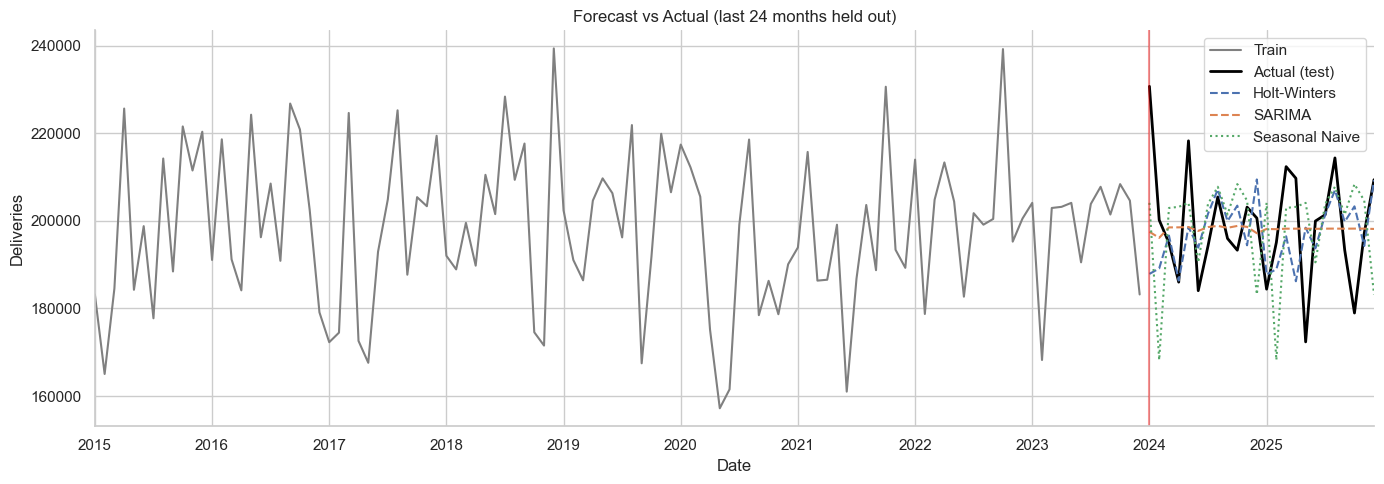

In [26]:
fig, ax = plt.subplots(figsize=(14, 5))
train_ts.plot(ax=ax, label='Train', color='gray')
test_ts.plot(ax=ax, label='Actual (test)', color='black', lw=2)
hw_fc.plot(ax=ax, label='Holt-Winters', ls='--')
sarima_fc.plot(ax=ax, label='SARIMA', ls='--')
snaive.plot(ax=ax, label='Seasonal Naive', ls=':')
ax.axvline(test_ts.index[0], color='red', alpha=0.4)
ax.set_title('Forecast vs Actual (last 24 months held out)')
ax.set_ylabel('Deliveries'); ax.legend()
plt.tight_layout(); plt.show()

### 7.5 Future forecast (next 12 months, 2026)
Refit the best model on the **full** series and project 12 months ahead with a confidence band.

Best forecasting model by RMSE: SARIMA


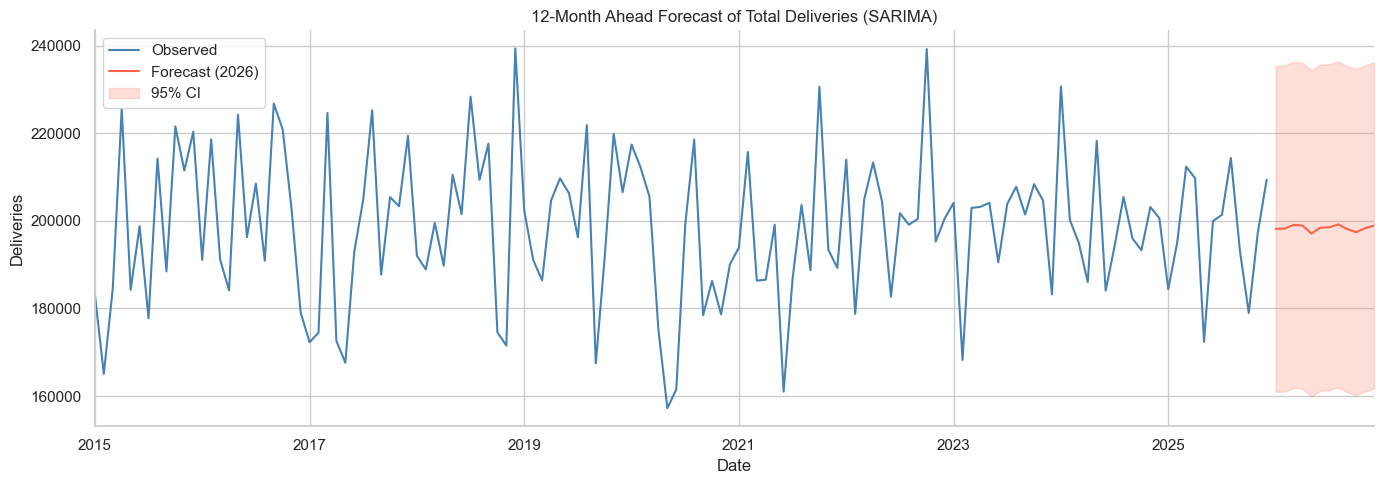

,Forecast,Lower95,Upper95
2026-01-01,198153.0,160988.0,235319.0
2026-02-01,198229.0,161022.0,235435.0
2026-03-01,199065.0,161859.0,236272.0
2026-04-01,198923.0,161716.0,236130.0
2026-05-01,197106.0,159899.0,234313.0
2026-06-01,198437.0,161230.0,235644.0
2026-07-01,198519.0,161312.0,235727.0
2026-08-01,199174.0,161967.0,236382.0
2026-09-01,198122.0,160914.0,235330.0
2026-10-01,197406.0,160198.0,234614.0


In [27]:
best_ts_name = ts_results.iloc[0]['Model']
print('Best forecasting model by RMSE:', best_ts_name)

# Refit SARIMA on the full series for the future projection (with prediction intervals)
final_model = SARIMAX(ts, order=(1, 1, 1), seasonal_order=(1, 0, 1, 12),
                      enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
fc = final_model.get_forecast(steps=12)
fc_mean = fc.predicted_mean
fc_ci = fc.conf_int()

fig, ax = plt.subplots(figsize=(14, 5))
ts.plot(ax=ax, label='Observed', color='steelblue')
fc_mean.plot(ax=ax, label='Forecast (2026)', color='tomato')
ax.fill_between(fc_ci.index, fc_ci.iloc[:, 0], fc_ci.iloc[:, 1],
                color='tomato', alpha=0.2, label='95% CI')
ax.set_title('12-Month Ahead Forecast of Total Deliveries (SARIMA)')
ax.set_ylabel('Deliveries'); ax.legend()
plt.tight_layout(); plt.show()

pd.DataFrame({'Forecast': fc_mean.round(0),
              'Lower95': fc_ci.iloc[:, 0].round(0),
              'Upper95': fc_ci.iloc[:, 1].round(0)})

---
## ✅ Conclusion & Key Takeaways

**Pipeline delivered (end-to-end):**
1. **Loading** — pulled the dataset from Kaggle via `kagglehub`.
2. **Preprocessing** — confirmed a clean, balanced 2,640-row panel (no nulls/duplicates) and built a datetime index.
3. **EDA** — uncovered the dominant structure: deliveries ≈ production, CO₂ saved is downstream of deliveries, and price is essentially random noise.
4. **Feature engineering** — added cyclical month features, a trend index, one-hot encoding, scaling, and **removed the `CO2_Saved_tons` leakage feature**.
5. **Regression** — compared 6 models; **all reached R² ≈ 0.98–0.99**, with **linear models (Lasso/Ridge) marginally ahead of the tree ensembles** because deliveries are a near-linear function of production. Predictions are driven **overwhelmingly by `Production_Units`** (importance ≈ 0.99).
6. **Tuning** — `RandomizedSearchCV` (5-fold, 25 candidates) refined the Random Forest; gains were marginal (the signal is already saturated) and residuals are centered near zero with no visible pattern.
7. **Forecasting** — decomposed the monthly series, confirmed stationarity (ADF p < 0.05), and benchmarked Seasonal-Naive vs Holt-Winters vs **SARIMA (best, ≈ 5% MAPE)**, then projected 2026.

**Honest caveats**
- The data is **synthetic**: deliveries carry little time trend (the series is stationary) and price is pure noise, so forecasts essentially track the seasonal mean and price is intentionally *not* modeled. The value here is the **methodology** — a reusable, leakage-safe pipeline that would extract real signal from real data.
- `Production_Units` so dominates the deliveries regression that it approaches a near-deterministic relationship; in a production setting we'd validate that this feature is actually available *before* delivery time.